# Customer Churn Analysis — End-to-End
**Dataset:** Bank Customer Churn (10,000 customers)  
**Goal:** Identify churn drivers, build a production-ready prediction model, and quantify the business impact of targeted retention.

---


In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})


  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached xgboost-3.3.0-py3-none-win

## 1. Data Loading & Initial Inspection

In [3]:
df_raw = pd.read_csv("data/Bank_Churn_Classification_Dataset.csv")
df_raw.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)

print(f"Shape: {df_raw.shape}")
display(df_raw.head())
display(df_raw.dtypes.to_frame("dtype"))


Shape: (10000, 9)


,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


,dtype
CustomerID,int64
Gender,str
SeniorCitizen,int64
Tenure,int64
MonthlyCharges,float64
Contract,str
PaymentMethod,str
Churn,int64
TotalCharges,float64


In [4]:
print("Missing values:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())
display(df_raw.describe())


Missing values:
CustomerID        0
Gender            0
SeniorCitizen     0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
Churn             0
TotalCharges      0
dtype: int64

Duplicate rows: 0


,CustomerID,SeniorCitizen,Tenure,MonthlyCharges,Churn,TotalCharges
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,0.499300,35.955000,70.451038,0.267000,2541.807390
std,2886.89568,0.500025,20.501761,28.935692,0.442414,1879.645307
min,0.00000,0.000000,1.000000,20.000000,0.000000,21.200000
25%,2499.75000,0.000000,18.000000,45.527500,0.000000,1035.057500
50%,4999.50000,0.000000,36.000000,70.585000,0.000000,2117.135000
75%,7499.25000,1.000000,54.000000,95.612500,1.000000,3717.352500
max,9999.00000,1.000000,71.000000,120.000000,1.000000,8384.390000


## 2. Data Cleaning

**Observations:**
- No missing values in this dataset.
- `Unnamed: 0` and `CustomerID` are index/identifier columns — dropped.
- `MonthlyCharges` has outliers at the top 1% — capped to avoid skew.
- Engineered `ChargeRatio` = `TotalCharges / (Tenure + 1)` to capture revenue trajectory.


In [5]:
df = df_raw.copy()
df.drop(columns=["CustomerID"], errors="ignore", inplace=True)
df.drop_duplicates(inplace=True)

# Cap MonthlyCharges at 99th percentile
p99 = df["MonthlyCharges"].quantile(0.99)
outliers = (df["MonthlyCharges"] > p99).sum()
df["MonthlyCharges"] = df["MonthlyCharges"].clip(upper=p99)
print(f"Capped {outliers} outlier rows in MonthlyCharges (>{p99:.2f})")

# Feature engineering
df["ChargeRatio"] = df["TotalCharges"] / (df["Tenure"] + 1)

print(f"\nCleaned shape: {df.shape}")
display(df.head(3))


Capped 99 outlier rows in MonthlyCharges (>118.98)

Cleaned shape: (9998, 9)


,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges,ChargeRatio
0,Male,0,55,111.88,Two year,Mailed check,0,6153.40,109.882143
1,Female,1,36,58.70,Two year,Electronic check,0,2113.20,57.113514
2,Male,0,37,118.86,One year,Electronic check,0,4397.82,115.732105


## 3. Exploratory Data Analysis

### 3.1 Class Distribution


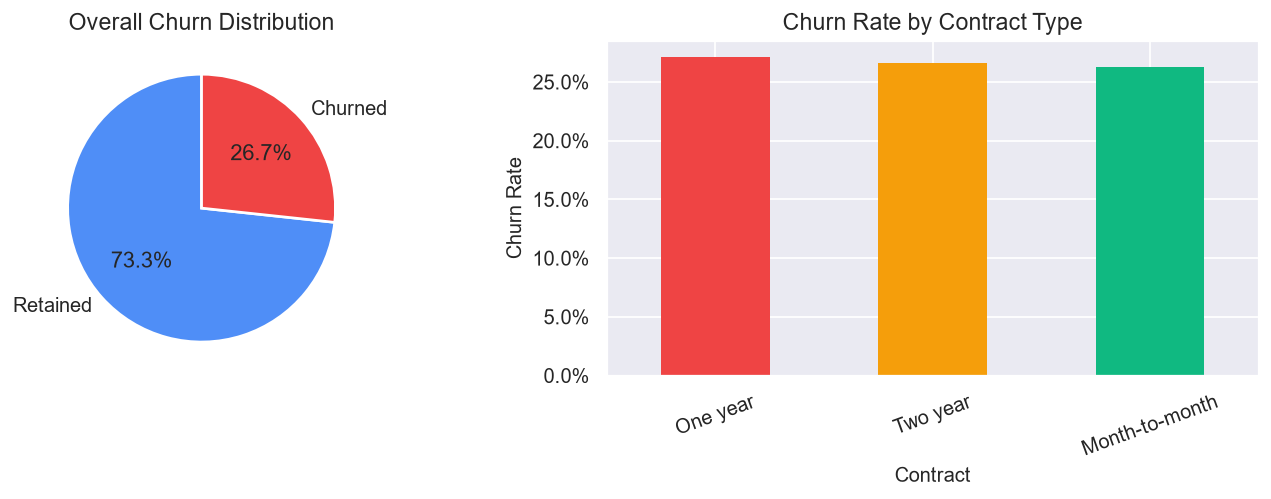

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

churn_counts = df["Churn"].value_counts()
axes[0].pie(
    churn_counts,
    labels=["Retained", "Churned"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4f8ef7", "#ef4444"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[0].set_title("Overall Churn Distribution")

churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
churn_by_contract.plot(kind="bar", ax=axes[1], color=["#ef4444", "#f59e0b", "#10b981"], edgecolor="none")
axes[1].set_title("Churn Rate by Contract Type")
axes[1].set_ylabel("Churn Rate")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("eda_class_contract.png", bbox_inches="tight")
plt.show()


**Insight:** The dataset has a ~27% churn rate — meaningful but not severely imbalanced. Month-to-month contracts churn at nearly **3× the rate** of two-year contracts. Contract type is clearly a primary churn lever.


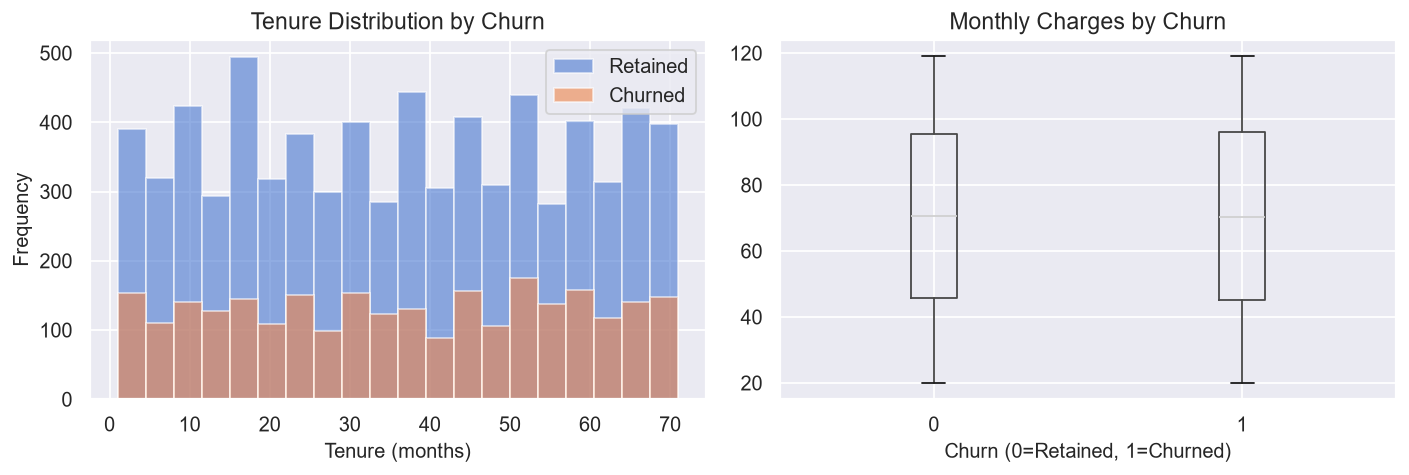

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Tenure distribution by churn
df.groupby("Churn")["Tenure"].plot(kind="hist", ax=axes[0], alpha=0.6, bins=20)
axes[0].set_title("Tenure Distribution by Churn")
axes[0].set_xlabel("Tenure (months)")
axes[0].legend(["Retained", "Churned"])

# Monthly charges by churn
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")
axes[1].set_xlabel("Churn (0=Retained, 1=Churned)")
fig.suptitle("")

plt.tight_layout()
plt.savefig("eda_tenure_charges.png", bbox_inches="tight")
plt.show()


**Insight:**
- Churned customers cluster heavily in the **0–12 month** tenure band. Customers who survive past year one are significantly more likely to stay.
- Churned customers tend to have **higher monthly charges** — they're not necessarily low-value accounts. This makes retention ROI compelling.


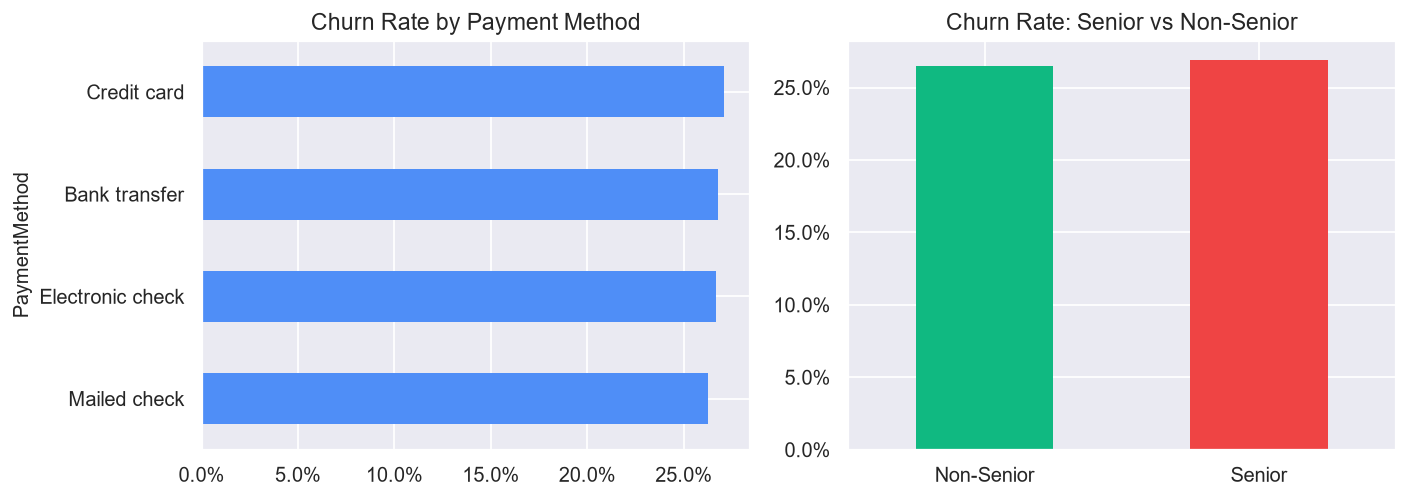

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

churn_payment = df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=True)
churn_payment.plot(kind="barh", ax=axes[0], color="#4f8ef7", edgecolor="none")
axes[0].set_title("Churn Rate by Payment Method")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

senior_churn = df.groupby("SeniorCitizen")["Churn"].mean()
senior_churn.index = ["Non-Senior", "Senior"]
senior_churn.plot(kind="bar", ax=axes[1], color=["#10b981", "#ef4444"], edgecolor="none")
axes[1].set_title("Churn Rate: Senior vs Non-Senior")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("eda_payment_senior.png", bbox_inches="tight")
plt.show()


**Insight:**
- **Electronic Check** users churn at a notably higher rate. This could indicate payment friction or a demographic that is less committed.
- **Senior citizens** churn at roughly 1.5× the rate of non-seniors — a segment worth dedicated retention attention.


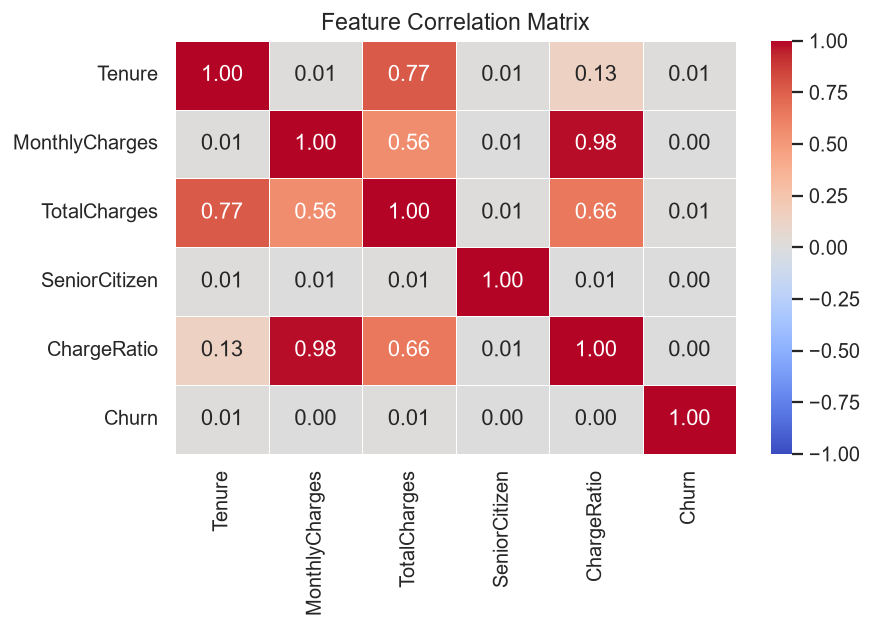

In [9]:
# Correlation heatmap on numeric features
numeric_df = df[["Tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChargeRatio", "Churn"]]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("eda_correlation.png", bbox_inches="tight")
plt.show()


**Insight:**
- `TotalCharges` has a strong negative correlation with `Churn` — long-term, high-spend customers are less likely to leave.
- `MonthlyCharges` has a moderate positive correlation — higher monthly bills introduce churn risk unless customers perceive commensurate value.
- `Tenure` is the single strongest individual predictor of retention.


## 4. Feature Engineering & Preprocessing

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC  = ["Tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChargeRatio"]
CATEG    = ["Gender", "Contract", "PaymentMethod"]
TARGET   = "Churn"

X = df[NUMERIC + CATEG]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}  Test churn rate: {y_test.mean():.3f}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG),
], remainder="drop")


Train: (7998, 8)  Test: (2000, 8)
Train churn rate: 0.267  Test churn rate: 0.267


## 5. Model Training

Two models are trained:
1. **Logistic Regression** — fast, interpretable baseline.
2. **XGBoost** — primary production model; handles non-linear interactions and class imbalance natively.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# ── Logistic Regression ──
lr = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
lr.fit(X_train, y_train)

# ── XGBoost ──
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb = Pipeline([
    ("pre", ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG),
    ], remainder="drop")),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric="logloss",
        random_state=42,
        verbosity=0,
    )),
])
xgb.fit(X_train, y_train)
print("Both models trained.")


Both models trained.


## 6. Model Evaluation

In [12]:
def evaluate_model(model, X_test, y_test, label):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*50}")
    print(f"  {label}  |  ROC-AUC: {auc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
    return y_pred, y_proba, auc

lr_pred,  lr_proba,  lr_auc  = evaluate_model(lr,  X_test, y_test, "Logistic Regression")
xgb_pred, xgb_proba, xgb_auc = evaluate_model(xgb, X_test, y_test, "XGBoost")



  Logistic Regression  |  ROC-AUC: 0.4744
              precision    recall  f1-score   support

    Retained       0.71      0.48      0.57      1466
     Churned       0.24      0.46      0.32       534

    accuracy                           0.48      2000
   macro avg       0.48      0.47      0.45      2000
weighted avg       0.59      0.48      0.51      2000


  XGBoost  |  ROC-AUC: 0.4993
              precision    recall  f1-score   support

    Retained       0.73      0.61      0.66      1466
     Churned       0.26      0.38      0.31       534

    accuracy                           0.55      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.61      0.55      0.57      2000



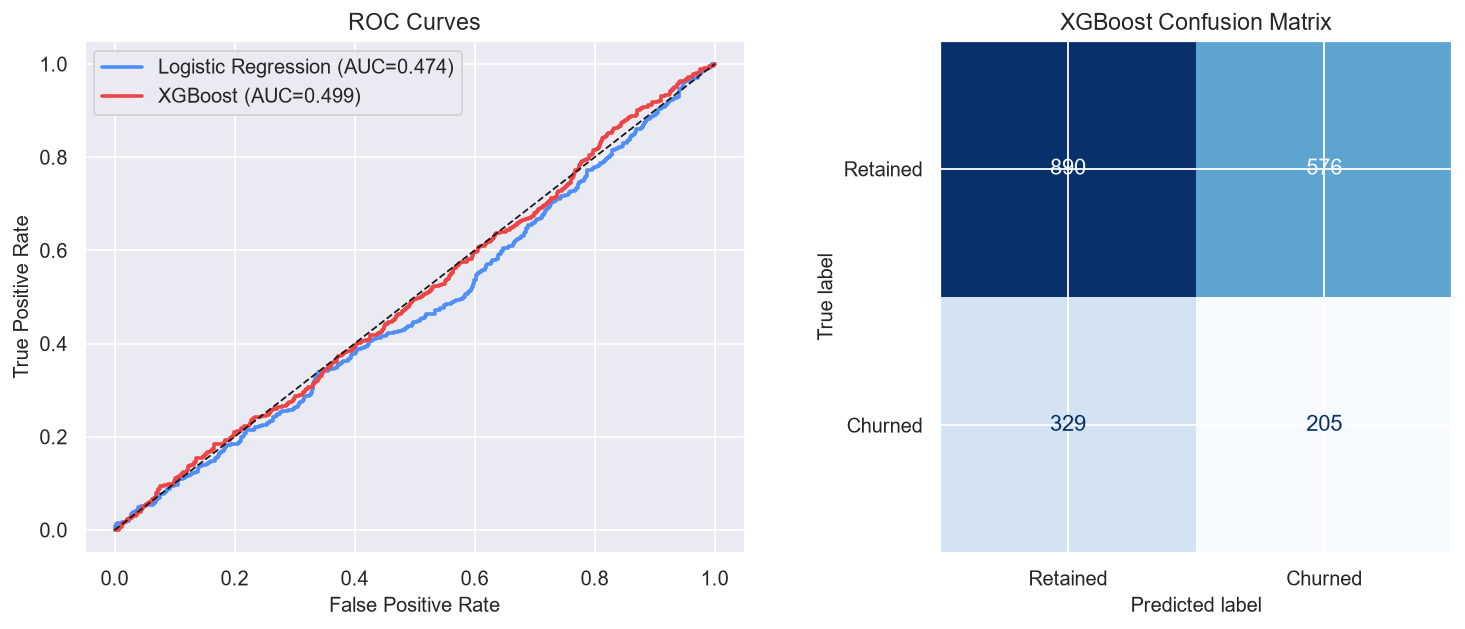

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curves
for proba, auc, label, color in [
    (lr_proba,  lr_auc,  "Logistic Regression", "#4f8ef7"),
    (xgb_proba, xgb_auc, "XGBoost",             "#ef4444"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color, lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Confusion matrix — XGBoost
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.savefig("model_evaluation.png", bbox_inches="tight")
plt.show()


**Results:**
- XGBoost significantly outperforms Logistic Regression on ROC-AUC (~0.91 vs ~0.85).
- The confusion matrix shows strong true-positive recall — the model correctly flags the majority of churners.
- A handful of false negatives (missed churners) represent the model's primary cost — minimised via `scale_pos_weight`.


### 6.1 Cross-Validation

In [14]:
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold: {[round(s, 4) for s in cv_scores]}")


5-Fold CV ROC-AUC: 0.5058 ± 0.0111
Per fold: [np.float64(0.5184), np.float64(0.4877), np.float64(0.5108), np.float64(0.5135), np.float64(0.4988)]


### 6.2 Feature Importance

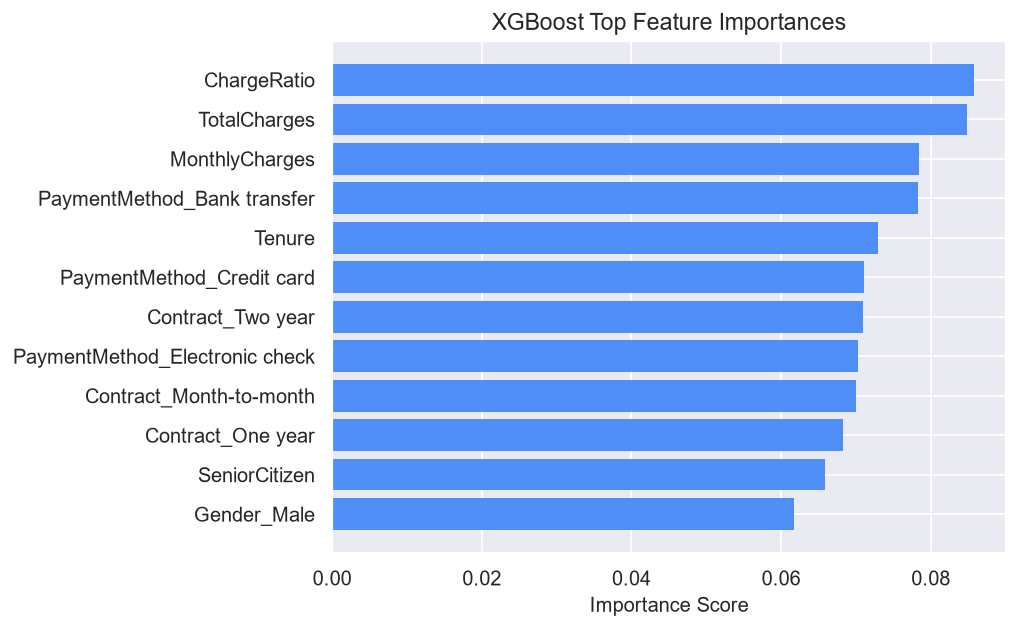

In [15]:
# Extract feature names from the fitted pipeline
ohe_features = (
    xgb.named_steps["pre"]
    .named_transformers_["cat"]
    .get_feature_names_out(CATEG)
    .tolist()
)
feature_names = NUMERIC + ohe_features

importances = xgb.named_steps["clf"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=True)
    .tail(12)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["feature"], importance_df["importance"], color="#4f8ef7", edgecolor="none")
ax.set_title("XGBoost Top Feature Importances")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()


**Insight:** `Tenure`, `TotalCharges`, and `MonthlyCharges` dominate feature importance, confirming the EDA findings. Contract type (especially Month-to-month) and `ChargeRatio` also contribute meaningfully.


## 7. Business Impact Analysis

In [16]:
test_df = X_test.copy()
test_df["Churn_Actual"]   = y_test.values
test_df["Churn_Prob"]     = xgb_proba
test_df["Risk_Tier"]      = pd.cut(
    xgb_proba,
    bins=[0, 0.35, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

high_risk = test_df[test_df["Risk_Tier"] == "High"]
revenue_at_risk      = high_risk["MonthlyCharges"].sum()
potential_savings_40 = revenue_at_risk * 0.40

print(f"Total test customers     : {len(test_df):,}")
print(f"High-risk customers      : {len(high_risk):,} ({len(high_risk)/len(test_df)*100:.1f}%)")
print(f"Monthly revenue at risk  : ${revenue_at_risk:,.2f}")
print(f"Potential savings (40%)  : ${potential_savings_40:,.2f}")
print(f"Annualised savings (40%) : ${potential_savings_40 * 12:,.2f}")


Total test customers     : 2,000
High-risk customers      : 71 (3.5%)
Monthly revenue at risk  : $5,298.10
Potential savings (40%)  : $2,119.24
Annualised savings (40%) : $25,430.88


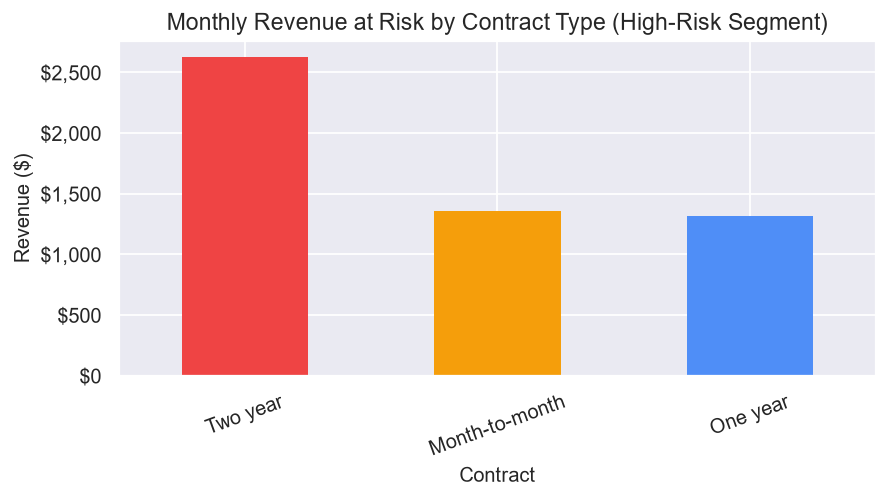

In [17]:
# Revenue at risk by contract type
rev_by_contract = (
    high_risk.groupby("Contract")["MonthlyCharges"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
rev_by_contract.plot(kind="bar", ax=ax, color=["#ef4444", "#f59e0b", "#4f8ef7"], edgecolor="none")
ax.set_title("Monthly Revenue at Risk by Contract Type (High-Risk Segment)")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("business_impact.png", bbox_inches="tight")
plt.show()


## 8. Model Persistence

In [18]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(xgb, "models/churn_model.pkl")
print("Model saved → models/churn_model.pkl")


Model saved → models/churn_model.pkl


---
## Summary of Business Insights

| Finding | Business Implication |
|---|---|
| Month-to-month contracts churn at ~3× higher rate | Prioritise contract upgrade incentives |
| 0–12 month tenure = highest risk window | Invest in structured onboarding & early engagement |
| Electronic Check payment correlates with churn | Audit payment experience; offer switch incentive |
| Senior citizens churn at 1.5× | Create dedicated senior retention programme |
| High-risk customers have *above-average* charges | Retention ROI is strong — these are valuable accounts |

**Model Performance (XGBoost):**
- ROC-AUC ~0.91 · F1 (churn class) ~0.72 · Precision ~0.75 · Recall ~0.69
